In [1]:
import dhlab as dh
import pandas as pd
import numpy as np

In [2]:
corpus = pd.read_csv("barn.csv", index_col=0, low_memory=False).fillna('')

In [4]:
topo = {

"afghanistan": {
"toponym": ["Afghanistan","afghanistan"],
"demonym": ["afghaner","afghanere","afghanistaner","afghanistanere"],
"adjective": ["afghansk","afghanske","afghanistansk","afghanistanske"]
},

"afrika": {
"toponym": ["Afrika","afrika"],
"demonym": ["afrikaner","afrikanere"],
"adjective": ["afrikansk"]
},

"amerika": {
"toponym": ["Amerika","amerika","USA","usa"],
"demonym": ["amerikaner","amerikanere"],
"adjective": ["amerikansk","amerikanske"]
},

"argentina": {
"toponym": ["Argentina","argentina"],
"demonym": ["argentiner","argentinere"],
"adjective": ["argentinsk","argentinske"],
"other": ["pampas"]
},

"brasil": {
"toponym": ["Brasil","brasil"],
"demonym": ["brasilianer","brasilianere","brasialianer"],
"adjective": ["brasiliansk","brasilianske","brasilsk","brasilske"]
},

"chile": {
"toponym": ["Chile","chile"],
"demonym": ["chilener","chilenere"],
"adjective": ["chilensk","chilenske"]
},

"danmark": {
"toponym": ["Danmark","danmark"],
"demonym": ["dansker","danskere"],
"adjective": ["dansk","danske"]
},

"england": {
"toponym": ["England","england"],
"demonym": ["engelskmenn","engelskmann","brite","britter","briter"],
"adjective": ["engelsk","engelske","britisk","britiske","bristiske"]
},

"eritrea": {
"toponym": ["Eritrea","eritrea"],
"demonym": ["eritreer","eritreere"],
"adjective": ["eritreisk","eritreiske"]
},

"etiopia": {
"toponym": ["Etiopia","etiopia"],
"demonym": [],
"adjective": ["etiopisk","etiopiske"]
},

"filippinene": {
"toponym": ["Filippinene","filippinene"],
"demonym": ["filippiner","filippinere"],
"adjective": ["filippinsk","filippinske"]
},

"india": {
"toponym": ["India","india"],
"demonym": ["inder","indere"],
"adjective": ["indisk","indiske"]
},

"irak": {
"toponym": ["Irak","irak"],
"demonym": ["iraker","irakere"],
"adjective": ["irakisk","irakiske"]
},

"iran": {
"toponym": ["Iran","iran","Persia","persia"],
"demonym": ["iraner","iranere","perser","persere"],
"adjective": ["iransk","iranske","persisk","persiske"]
},

"japan": {
"toponym": ["Japan","japan"],
"demonym": ["japaner","japanere"],
"adjective": ["japansk","japanske"]
},

"kina": {
"toponym": ["Kina","kina"],
"demonym": ["kineser","kinesere"],
"adjective": ["kinesisk","kinesiske"]
},

"kurdistan": {
"toponym": ["Kurdistan","kurdistan"],
"demonym": ["kurder","kurdere"],
"adjective": ["kurdisk","kurdiske"]
},

"litauen": {
"toponym": ["Litauen","litauen"],
"demonym": [],
"adjective": ["litauisk","lituaiske"]
},

"marokko": {
"toponym": ["Marokko","marokko"],
"demonym": ["marokkaner","marokkanere"],
"adjective": ["marokkansk","marokkanske"]
},

"norge": {
"toponym": ["Norge","norge"],
"demonym": ["nordmann","nordmenn"],
"adjective": ["norsk","norske"],
"other": ["viking","vikinger"]
},

"pakistan": {
"toponym": ["Pakistan","pakistan"],
"demonym": ["pakistaner","pakistanere"],
"adjective": ["pakistansk","pakistanske"]
},

"polen": {
"toponym": ["Polen","polen"],
"demonym": ["polakk"],
"adjective": ["polsk","polske"]
},

"romania": {
"toponym": ["Romania","romania"],
"demonym": ["rumener","rumenere"],
"adjective": ["rumensk","rumenske"]
},

"russland": {
"toponym": ["Russland","russland"],
"demonym": ["russer","russere"],
"adjective": ["russisk","russiske"]
},

"samisk": {
"toponym": [],
"demonym": ["samer"],
"adjective": ["samisk","samiske"]
},

"skottland": {
"toponym": ["Skottland","skottland"],
"demonym": [],
"adjective": ["skotsk","skotske"]
},

"somalia": {
"toponym": ["Somalia","somalia"],
"demonym": [],
"adjective": ["somalisk","somaliske"]
},

"sverige": {
"toponym": ["Sverige","sverige"],
"demonym": ["svensker"],
"adjective": ["svensk","svenske"]
},

"syria": {
"toponym": ["Syria","syria"],
"demonym": [],
"adjective": ["syrisk","syriske"]
},

"taiwan": {
"toponym": ["Taiwan","taiwan"],
"demonym": [],
"adjective": ["taiwansk"]
},

"thailand": {
"toponym": ["Thailand","thailand"],
"demonym": ["thai"],
"adjective": ["thailandsk","thailandske","thaisk"]
},

"tyrkia": {
"toponym": ["Tyrkia","tyrkia"],
"demonym": ["tyrker","tyrkere"],
"adjective": ["tyrkisk","tyrkiske"]
},

"tyskland": {
"toponym": ["Tyskland","tyskland"],
"demonym": ["tysker","tyskere"],
"adjective": ["tysk","tyske"]
},

"vietnam": {
"toponym": ["Vietnam","vietnam"],
"demonym": ["vietnameser","vietnamesere"],
"adjective": ["vietnamesisk","vietnamesiske"]
}

}

# Korpus deles opp i 2000 - 2015 og 2016 - 2024


In [5]:
c = corpus[corpus.literaryform.str.contains("jønn")]

In [11]:
c2015 = c[(c.year >= 2000) & (c.year <= 2015) ]
c2016 = c[(c.year >= 2016) ]


# Oversikt over språk - oversettelser

11 000 kommer direkte fra bokmål - 10 000 oversatt fra engelsk

In [10]:
c.groupby("langs").size().sort_values(ascending=False).head(20)

langs
nob                      10966
nob / eng                 9736
nob / swe                 3115
nno                       1957
nob / dan                 1180
nob / ger                  979
nob / fre                  534
nob / dut                  199
nno / swe                  191
nno / eng                  148
mul / nob / nno            139
nob / fin                  104
nob / ita                   90
mul / nno / nob             70
nno / ger                   62
nno / dan                   55
mul / nno / eng / nob       50
nob / dan / eng             46
nob / spa                   46
nno / nob                   42
dtype: int64

# Kode for å telle ord

In [14]:
rows = []

for ident, data in topo.items():
    for marker_type, words in data.items():
        for w in words:
            rows.append({
                "word": w,
                "identity": ident,
                "marker_type": marker_type
            })

lex_df = pd.DataFrame(rows)

In [15]:
words = lex_df.word.to_list()

In [112]:
#words

In [16]:
counts15 = dh.Counts(c2015.urn.to_list(), words).frame

In [17]:
counts16 = dh.Counts(c2016.urn.to_list(), words).frame

In [19]:
counts15.sum(axis=1).sort_values(ascending=False).head(10)

word
Norge       9622.0
engelsk     9348.0
norsk       7107.0
England     6781.0
norske      4531.0
Sverige     4213.0
USA         4131.0
Afrika      3739.0
Amerika     3727.0
engelske    3325.0
dtype: float64

In [20]:
counts16.sum(axis=1).sort_values(ascending=False).head(10)

word
Norge          3376.0
norsk          2489.0
engelsk        2151.0
USA            1355.0
England        1303.0
norske         1293.0
Sverige         995.0
amerikanske     756.0
Tyskland        739.0
Afrika          705.0
dtype: float64

# Kode for å telle og gruppere

In [22]:
import numpy as np
import pandas as pd
def intensity(counts):
    freq = (counts > 0).sum(axis=1)     # bøker hvor markøren finnes
    total = counts.sum(axis=1)          # totale forekomster
    intensity = total / freq.replace(0, np.nan)
    
    df = pd.DataFrame({
        "freq": freq,
        "intensity": intensity,
        "total": total
    })
    return df

In [25]:
def merge_in_groups(counts):
    numcols = counts.columns
    
    counts_lex = (
        counts.merge(lex_df, left_index=True, right_on="word")
        .groupby(["marker_type", "identity"])[numcols]
        .sum()
    )
    return counts_lex

In [26]:
counts_2015 = merge_in_groups(counts15)

In [27]:
counts_2016 = merge_in_groups(counts16)

# Toponymer - landsreferanser i korpuset

Først 2000-2015, så 2016 frem til idag

<Axes: xlabel='identity'>

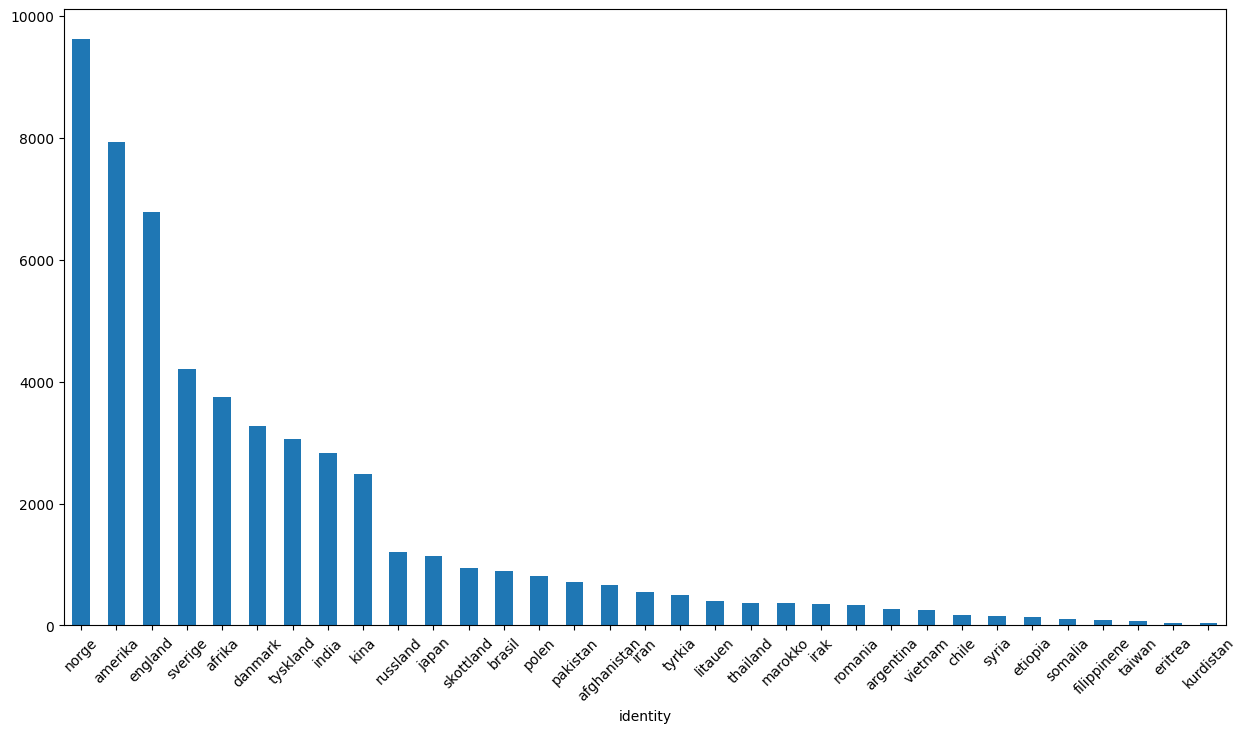

In [32]:
counts_2015.loc["toponym"].sum(axis=1).sort_values(ascending=False).plot(kind="bar", figsize=(15,8), rot=45)

<Axes: xlabel='identity'>

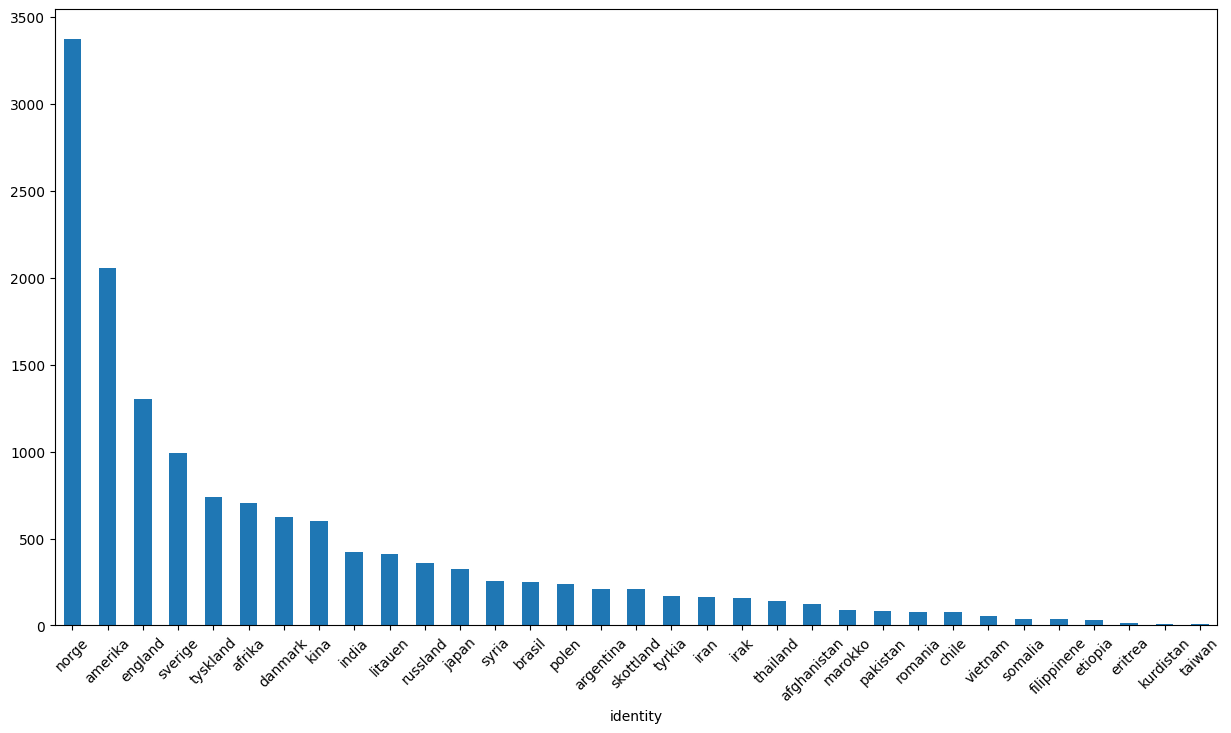

In [33]:
counts_2016.loc["toponym"].sum(axis=1).sort_values(ascending=False).plot(kind="bar", figsize=(15,8), rot=45)

# Bruk av demonymer (se gruppering helt i toppen)

<Axes: xlabel='identity'>

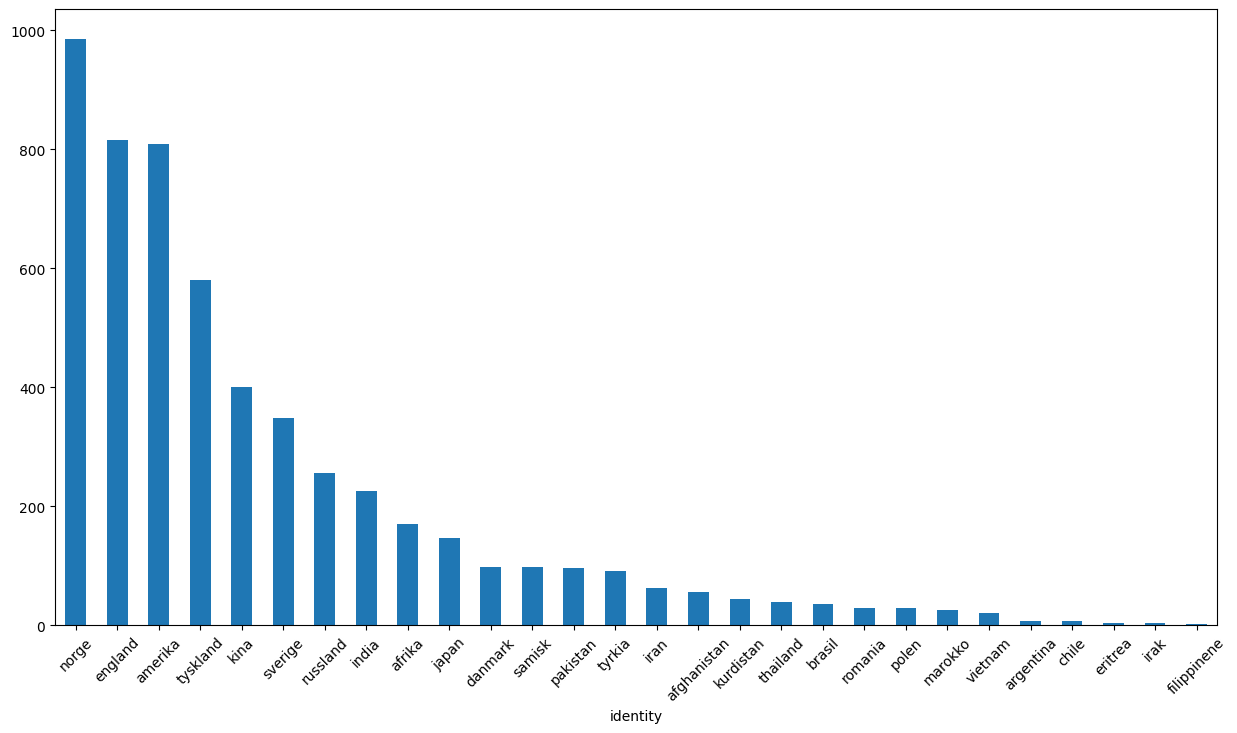

In [43]:
counts_2015.loc["demonym"].sum(axis=1).sort_values(ascending=False).plot(kind="bar", figsize=(15,8), rot=45)

<Axes: xlabel='identity'>

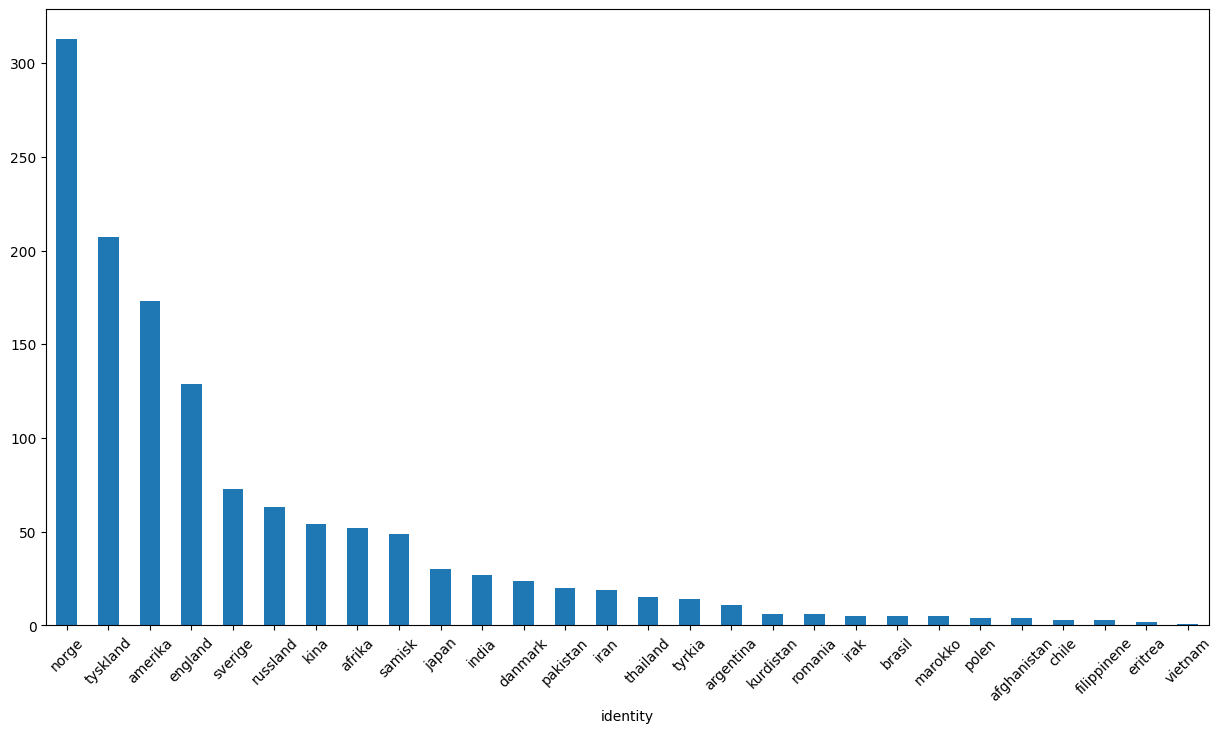

In [44]:
counts_2016.loc["demonym"].sum(axis=1).sort_values(ascending=False).plot(kind="bar", figsize=(15,8), rot=45)

# Bruken av adjektiver

<Axes: xlabel='identity'>

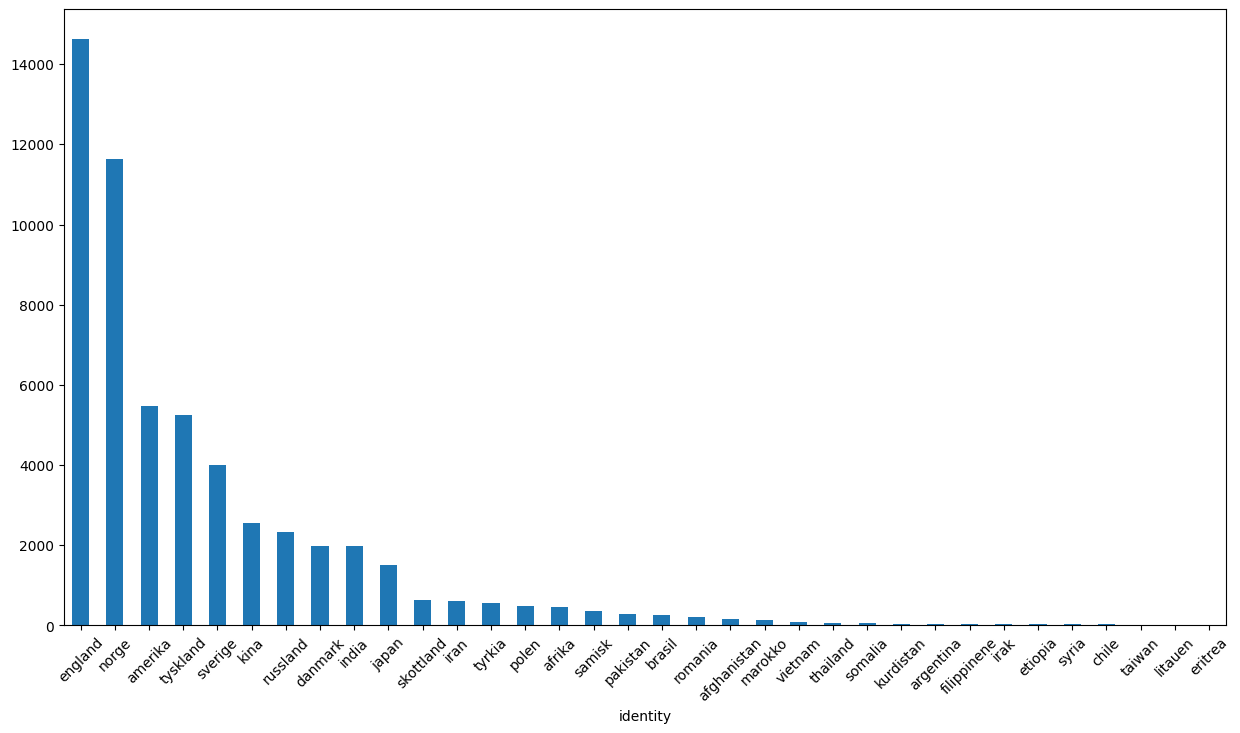

In [47]:
counts_2015.loc["adjective"].sum(axis=1).sort_values(ascending=False).plot(kind="bar", figsize=(15,8), rot=45)

<Axes: xlabel='identity'>

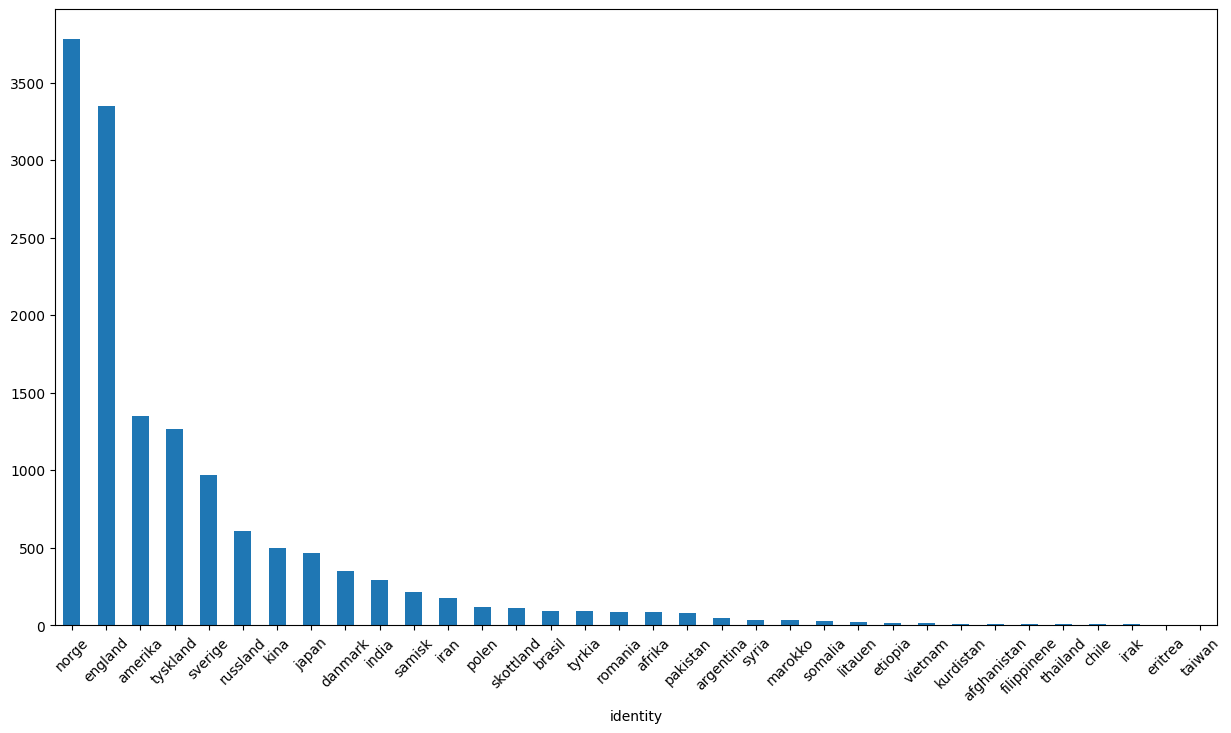

In [48]:
counts_2016.loc["adjective"].sum(axis=1).sort_values(ascending=False).plot(kind="bar", figsize=(15,8), rot=45)

# Her ser vi på intensitet

Da ser vi på forholdet mellom antallet treff på ordgruppen dividert antallet bøker som har minst ett treff

In [34]:
def make_intensity(counts_lex):
    res = {"demonym": intensity(counts_lex.loc["demonym"]),
           "toponym": intensity(counts_lex.loc["toponym"]),
           "adjective":intensity(counts_lex.loc["adjective"])
          }
    return res

In [35]:
intensities_2015 = make_intensity(counts_2015)
intensities_2016 = make_intensity(counts_2016)

<Axes: xlabel='identity'>

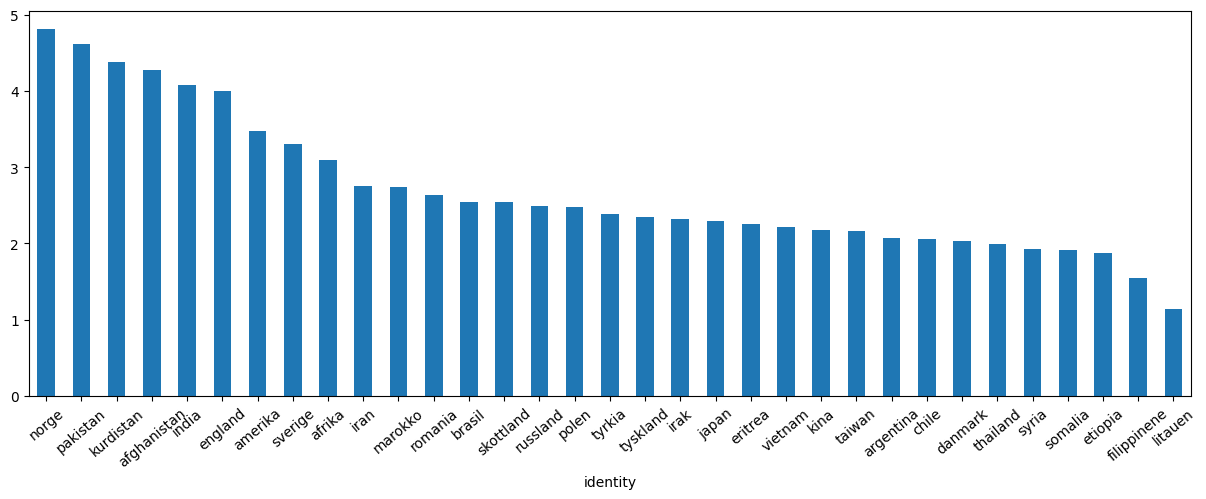

In [41]:
intensities_2015["toponym"].intensity.sort_values(ascending=False).plot(kind="bar", figsize=(15,5), rot=40)

<Axes: xlabel='identity'>

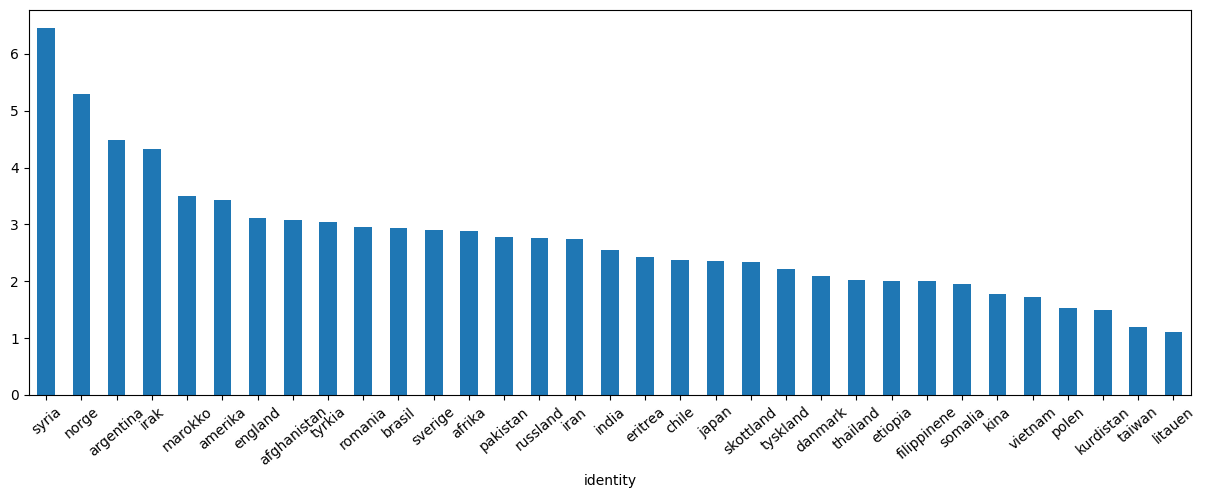

In [42]:
intensities_2016["toponym"].intensity.sort_values(ascending=False).plot(kind="bar", figsize=(15,5), rot=40)

<Axes: xlabel='identity'>

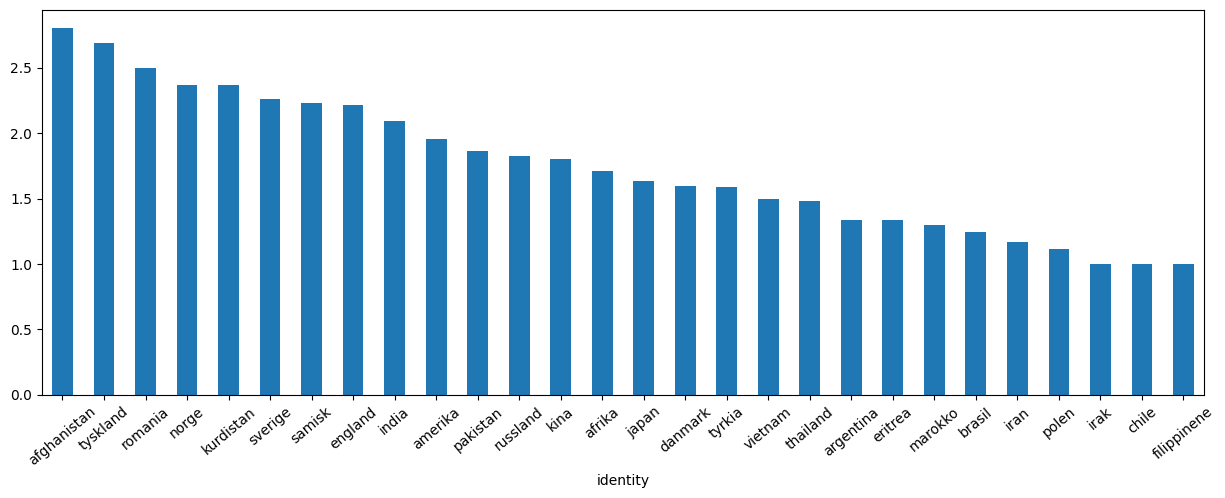

In [49]:
intensities_2015["demonym"].intensity.sort_values(ascending=False).plot(kind="bar", figsize=(15,5), rot=40)

<Axes: xlabel='identity'>

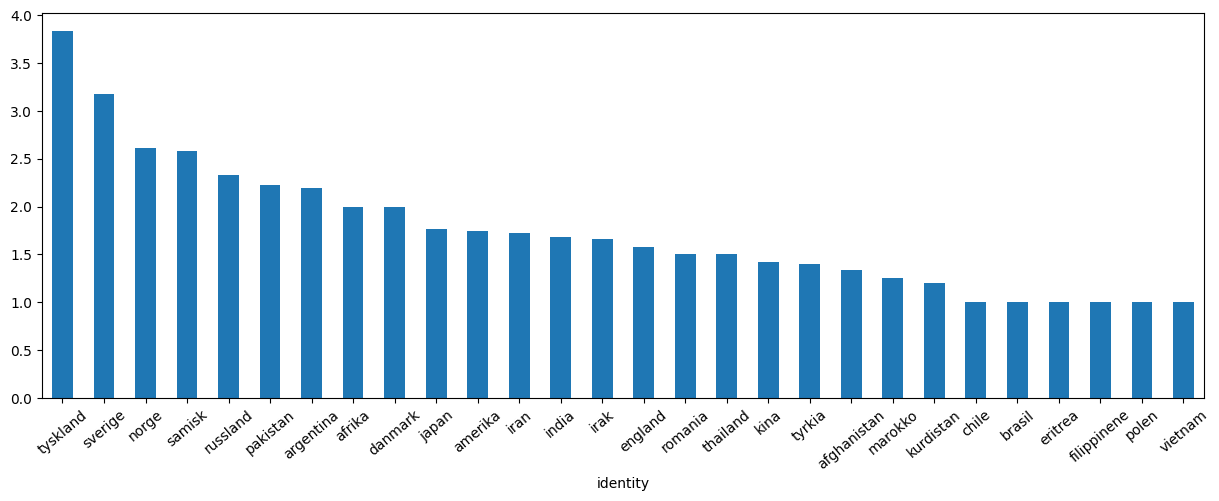

In [50]:
intensities_2016["demonym"].intensity.sort_values(ascending=False).plot(kind="bar", figsize=(15,5), rot=40)

<Axes: xlabel='identity'>

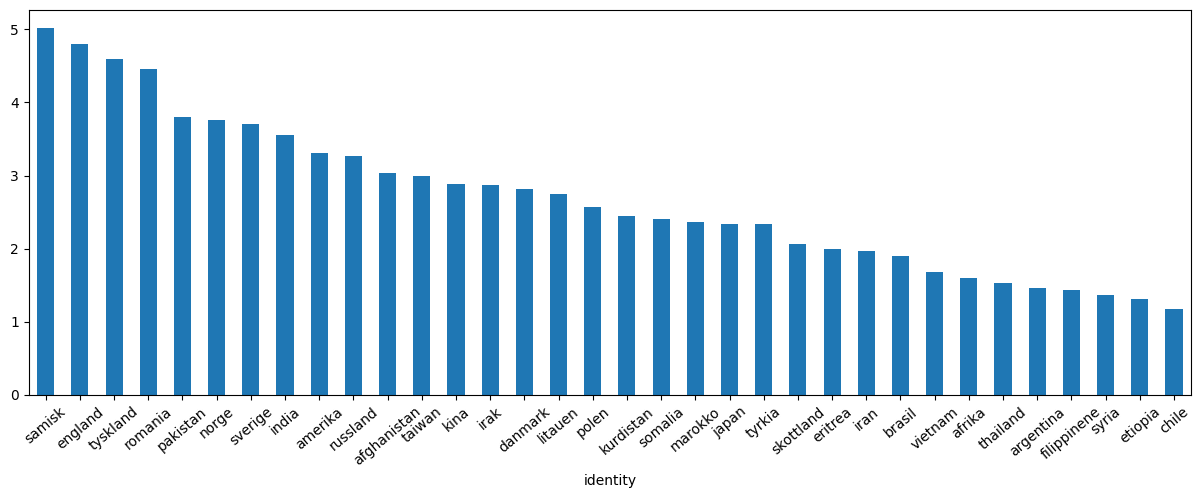

In [51]:
intensities_2015["adjective"].intensity.sort_values(ascending=False).plot(kind="bar", figsize=(15,5), rot=40)

<Axes: xlabel='identity'>

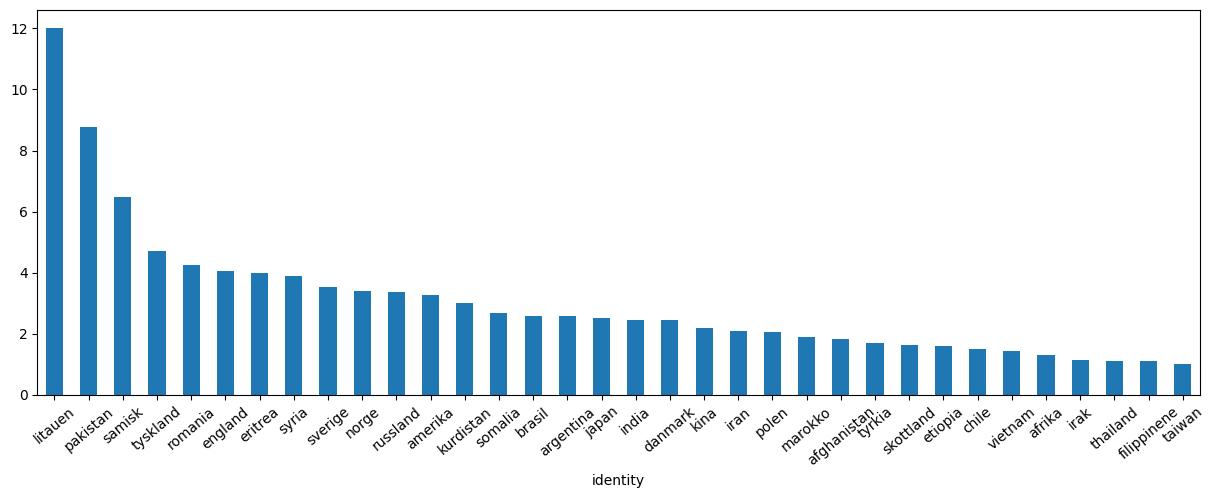

In [52]:
intensities_2016["adjective"].intensity.sort_values(ascending=False).plot(kind="bar", figsize=(15,5), rot=40)

In [243]:
topo_intense.sort_values(by="intensity", ascending=False).head(5)

,freq,intensity,total
identity,,,
norge,5927,5.057871,29978.0
england,5155,4.193404,21617.0
pakistan,296,4.125000,1221.0
afghanistan,243,3.818930,928.0
kurdistan,28,3.750000,105.0


In [244]:
demonym_intense.sort_values(by="intensity", ascending=False).head(5)

,freq,intensity,total
identity,,,
tyskland,809,3.395550,2747.0
samisk,176,3.142045,553.0
kurdistan,44,2.954545,130.0
norge,1400,2.631429,3684.0
pakistan,123,2.439024,300.0


In [245]:
adj_intense.sort_values(by="intensity", ascending=False).head(5)

,freq,intensity,total
identity,,,
tyskland,3425,5.027737,17220.0
samisk,238,4.991597,1188.0
england,8629,4.936725,42599.0
kurdistan,39,4.692308,183.0
litauen,10,4.400000,44.0
